In [1]:
# 訓練データとテストデータの画像を読み込む
# （サイズは縦横224pxにリサイズする）
import tensorflow as tf

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/train",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=True
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/test",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=False
)

# 分類名（dog／cat）をリストとして格納する
class_names = train_dataset.class_names
class_names



/Users/MisayoMacBookPro/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Found 300 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


['cat', 'dog']

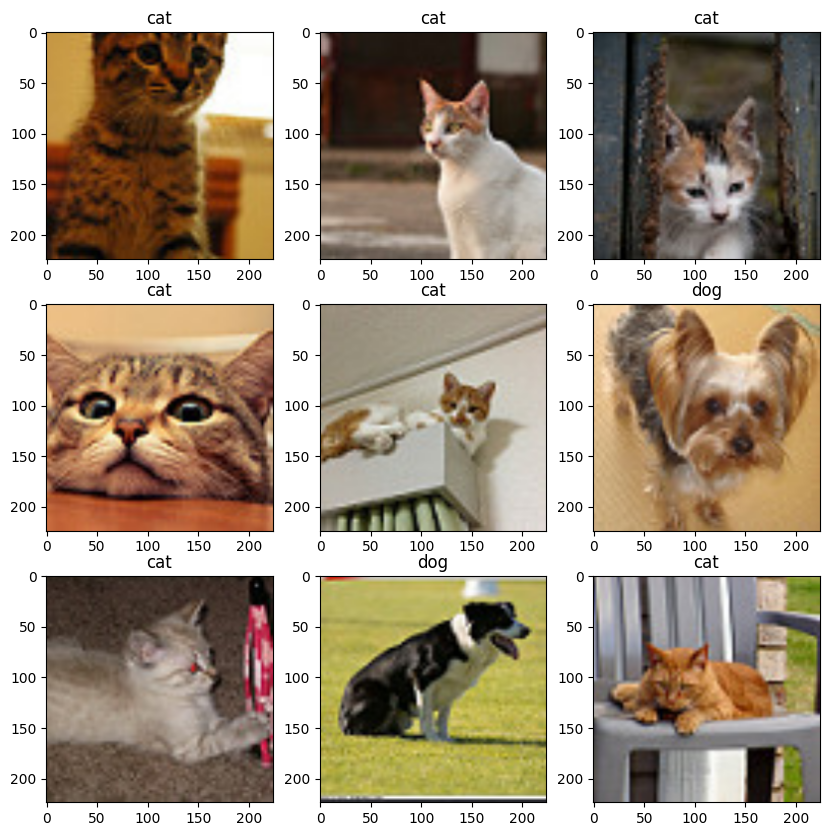

In [4]:
# 訓練データの一部を表示して確認
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [5]:
# 画像の水増しをする関数の定義
def flip_left_right(image, label):   # 左右反転
    image = tf.image.flip_left_right(image)
    return image, label

def flip_up_down(image, label):      # 上下反転
    image = tf.image.flip_up_down(image)
    return image, label

def rot90(image, label):             # 反時計回りに90度回転
    image = tf.image.rot90(image)
    return image, label

def rot180(image, label):            # 反時計回りに180度回転
    image = tf.image.rot90(image, k=2)
    return image, label

def rot270(image, label):            # 反時計回りに270度回転
    image = tf.image.rot90(image, k=3)
    return image, label


# 画像の水増し処理の実行
train_dataset_lr     = train_dataset.map(flip_left_right)
train_dataset_ud     = train_dataset.map(flip_up_down)
train_dataset_rot90  = train_dataset.map(rot90)
train_dataset_rot180 = train_dataset.map(rot180)
train_dataset_rot270 = train_dataset.map(rot270)



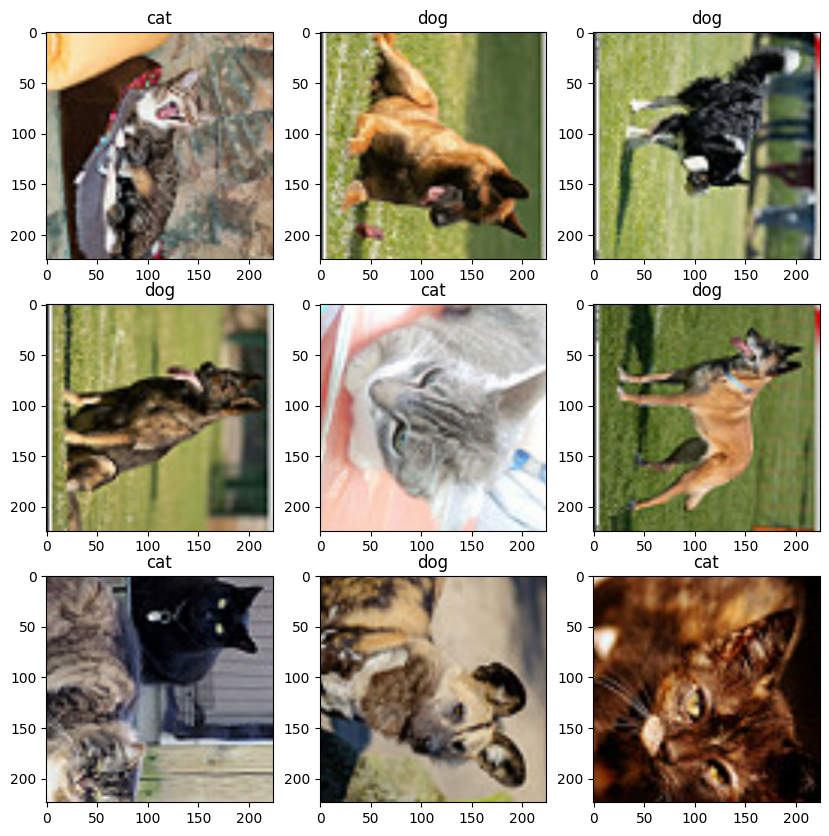

In [12]:
# 水増ししたデータを訓練データに追加する
train_dataset = train_dataset.concatenate(train_dataset_lr)
train_dataset = train_dataset.concatenate(train_dataset_ud)
train_dataset = train_dataset.concatenate(train_dataset_rot90)
train_dataset = train_dataset.concatenate(train_dataset_rot180)
train_dataset = train_dataset.concatenate(train_dataset_rot270)

# データをシャッフルする
train_dataset = train_dataset.shuffle(32)

# 訓練データの一部を表示して確認
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [34]:
# MobileNetV2モデルを作成する
input_layer = tf.keras.Input(shape=(224, 224, 3))   # 入力層
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer)   # 前処理（正規化）をする層

base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(
    input_shape=(224, 224, 3),
    input_tensor=l_layer,
    include_top=False,
    weights="imagenet",
    pooling='avg'
)
base_model.trainable = False


# Dense層を追加する
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')

# base_modelに先ほどのDense層を追加したモデルを作成する
model = tf.keras.Sequential([
    base_model,
    output_layer
])


# modelをcompileする
model.compile(optimizer="adam",
              loss='binary_crossentropy',
              metrics=["accuracy"])


# modelに学習させる
model.fit(train_dataset, epochs=20)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 16s 232ms/step - accuracy: 0.7567 - loss: 0.4775
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 220ms/step - accuracy: 0.9072 - loss: 0.2406
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 219ms/step - accuracy: 0.9356 - loss: 0.1870
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 221ms/step - accuracy: 0.9511 - loss: 0.1497
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 230ms/step - accuracy: 0.9628 - loss: 0.1269
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 228ms/step - accuracy: 0.9694 - loss: 0.1108
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 227ms/step - accuracy: 0.9767 - loss: 0.0981
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 226ms/step - accuracy: 0.9828 - loss: 0.0851
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 231ms/step - accuracy: 0.9833 - loss: 0.0774
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 233ms/step - accuracy: 0.9872 - loss: 0.0704
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9878 - loss: 0.0637
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 108s 

In [ ]:
# テストデータで分類を実行する
pred_data = model.predict(test_dataset)

print(pred_data)  #1.8004324e-04というのは0.18004324という意味らしい


# evaluate()でモデルの性能を評価する
model.evaluate(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 314ms/step
[[1.8004324e-04]
 [2.8723667e-04]
 [8.2487168e-05]
 [1.8078880e-03]
 [5.7847652e-04]
 [3.8173315e-04]
 [7.4759527e-04]
 [4.3563024e-04]
 [2.6234815e-05]
 [7.5474853e-04]
 [8.1863174e-05]
 [6.7424998e-03]
 [6.0627414e-03]
 [4.2327028e-04]
 [4.5497669e-05]
 [1.4678357e-05]
 [1.5366888e-04]
 [6.8731490e-04]
 [6.5676873e-03]
 [4.5326613e-03]
 [8.0512539e-03]
 [4.8429690e-02]
 [4.9212631e-03]
 [8.7113393e-04]
 [3.5808328e-01]
 [1.1779839e-03]
 [1.3520655e-03]
 [8.3245686e-04]
 [5.8839847e-03]
 [3.0593548e-04]
 [1.4233399e-03]
 [6.4666283e-01]
 [1.9698449e-04]
 [9.6418284e-04]
 [3.4504493e-03]
 [9.0400457e-01]
 [2.6555548e-03]
 [2.9516302e-03]
 [3.4096915e-02]
 [5.6166353e-04]
 [3.6596623e-04]
 [1.2892046e-03]
 [2.5989329e-02]
 [1.5547837e-04]
 [1.0808355e-03]
 [8.7241545e-02]
 [5.5284431e-04]
 [2.0855558e-03]
 [8.6287428e-03]
 [8.7221400e-05]
 [9.9424279e-01]
 [9.9976295e-01]
 [9.9994344e-01]
 [9.9966574e-01]
 [9.9925256e-01]
 [5.5403531e-01]
 [9.99992

[0.0587630420923233, 0.9700000286102295]